# Online Retail II: Exploratory Data Analysis & Business Insights

This notebook performs a comprehensive exploratory data analysis (EDA) of the **Online Retail II** dataset, which contains all transactions occurring between 01/12/2009 and 09/12/2011 for a UK-based, non-store online retail business.

### Objectives:
1. **Data Loading & Structure Check**: Load two-year sheets, display shapes, columns, and data types.
2. **Data Quality Audit**: Report missing values and duplicate records without modifying the data (observation only).
3. **Product Performance**: Identify the top 10 best-selling products by quantity sold and revenue generated.
4. **Geographic Distribution**: Evaluate sales performance by country.
5. **Temporal Patterns**: Plot the monthly revenue trend over time.
6. **Correlation Analysis**: Analyze relationships between key numerical variables.
7. **Outlier Detection**: Visualize and discuss anomalies using box plots.
8. **Business Insights**: Derive actionable business conclusions based on findings.

> **Note**: As per requirements, no rows or data points (including duplicates, nulls, and negative values representing cancellations/adjustments) are removed during this analysis phase. This is an observation-only study.

## Setup and Configurations
We import the necessary libraries and configure plotting aesthetics for a premium appearance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

# Set plotting aesthetics for premium look
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

import warnings
warnings.filterwarnings('ignore')

## Loading the Dataset
The dataset consists of two sheets: one for Year 2009-2010 and another for Year 2010-2011. We load both, concatenate them, and compute `Revenue = Quantity * Price` for our analysis.

In [2]:
file_path = "online_retail_II.xlsx"

print("Loading 'Year 2009-2010' sheet...")
df_2009_2010 = pd.read_excel(file_path, sheet_name="Year 2009-2010")

print("Loading 'Year 2010-2011' sheet...")
df_2010_2011 = pd.read_excel(file_path, sheet_name="Year 2010-2011")

print("Concatenating sheets into combined dataframe...")
df = pd.concat([df_2009_2010, df_2010_2011], ignore_index=True)

# Compute Revenue
df['Revenue'] = df['Quantity'] * df['Price']

print("Dataset combined and Revenue column added successfully!")

Loading 'Year 2009-2010' sheet...


Loading 'Year 2010-2011' sheet...


Concatenating sheets into combined dataframe...
Dataset combined and Revenue column added successfully!


## 1. Basic Information and Structure
We display individual and combined shapes, column names, data types, and inspect the first few rows of the data.

In [3]:
print(f"Shape of Year 2009-2010: {df_2009_2010.shape}")
print(f"Shape of Year 2010-2011: {df_2010_2011.shape}")
print(f"Shape of Combined Dataset: {df.shape}")
print("\nColumns in the dataset:")
print(list(df.columns))
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 rows of the combined dataset:")
df.head()

Shape of Year 2009-2010: (525461, 8)
Shape of Year 2010-2011: (541910, 8)
Shape of Combined Dataset: (1067371, 9)

Columns in the dataset:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue']

Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
Revenue               float64
dtype: object

First 5 rows of the combined dataset:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


## 2. Missing Values and Duplicate Rows
We report the number of missing values per column and count duplicate rows in the combined dataset.

In [4]:
# Missing values
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df)) * 100
missing_report = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage (%)': missing_percentages
})
print("--- Missing Values Report ---")
print(missing_report)

# Duplicate rows
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100
print("\n--- Duplicate Rows Report ---")
print(f"Total duplicate rows: {duplicate_count:,} ({duplicate_percentage:.2f}%)")

--- Missing Values Report ---
             Missing Count  Percentage (%)
Invoice                  0        0.000000
StockCode                0        0.000000
Description           4382        0.410541
Quantity                 0        0.000000
InvoiceDate              0        0.000000
Price                    0        0.000000
Customer ID         243007       22.766873
Country                  0        0.000000
Revenue                  0        0.000000



--- Duplicate Rows Report ---
Total duplicate rows: 34,335 (3.22%)


## 3. Top 10 Best-Selling Products
We aggregate by `StockCode` and `Description` to identify the top 10 products by:
1. **Total Quantity Sold**
2. **Total Revenue Generated**

In [5]:
# Create copy to fill missing descriptions for aggregation
df_grouped = df.copy()
df_grouped['Description'] = df_grouped['Description'].fillna("UNKNOWN PRODUCT")

# Top 10 by Quantity
top_qty = df_grouped.groupby(['StockCode', 'Description'])['Quantity'].sum().reset_index()
top_qty_sorted = top_qty.sort_values(by='Quantity', ascending=False).head(10)

print("--- Top 10 Products by Quantity ---")
display(top_qty_sorted.style.format({'Quantity': '{:,}'}))

# Top 10 by Revenue
top_revenue = df_grouped.groupby(['StockCode', 'Description'])['Revenue'].sum().reset_index()
top_rev_sorted = top_revenue.sort_values(by='Revenue', ascending=False).head(10)

print("\n--- Top 10 Products by Revenue ---")
display(top_rev_sorted.style.format({'Revenue': '${:,.2f}'}))

--- Top 10 Products by Quantity ---


,StockCode,Description,Quantity
5350,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,"108,545"
8325,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"92,453"
5683,84879,ASSORTED COLOUR BIRD ORNAMENT,"81,306"
8300,85099B,JUMBO BAG RED RETROSPOT,"77,671"
93,17003,BROCADE RING PURSE,"70,700"
2186,21977,PACK OF 60 PINK PAISLEY CAKE CASES,"56,575"
5780,84991,60 TEATIME FAIRY CAKE CASES,"54,366"
2524,22197,SMALL POPCORN HOLDER,"49,616"
979,21212,PACK OF 72 RETROSPOT CAKE CASES,"49,344"
978,21212,PACK OF 72 RETRO SPOT CAKE CASES,"46,106"



--- Top 10 Products by Revenue ---


,StockCode,Description,Revenue
2870,22423,REGENCY CAKESTAND 3 TIER,"$327,813.65"
8990,DOT,DOTCOM POSTAGE,"$322,647.47"
8325,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"$253,541.51"
5008,47566,PARTY BUNTING,"$147,948.50"
8300,85099B,JUMBO BAG RED RETROSPOT,"$146,689.00"
5683,84879,ASSORTED COLOUR BIRD ORNAMENT,"$131,413.85"
2324,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"$121,662.14"
8995,POST,POSTAGE,"$112,341.00"
5241,79321,CHILLI LIGHTS,"$84,854.16"
5387,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,"$73,814.72"


## 4. Sales Performance by Country
We evaluate sales performance by Country, calculating total quantity, total revenue, and unique transactions.

In [6]:
country_perf = df.groupby('Country').agg(
    Total_Quantity=('Quantity', 'sum'),
    Total_Revenue=('Revenue', 'sum'),
    Unique_Transactions=('Invoice', 'nunique')
).reset_index()

country_perf_sorted = country_perf.sort_values(by='Total_Revenue', ascending=False)

print("--- Sales Performance by Country (Top 10 by Revenue) ---")
display(country_perf_sorted.head(10).style.format({
    'Total_Quantity': '{:,}',
    'Total_Revenue': '${:,.2f}',
    'Unique_Transactions': '{:,}'
}))

--- Sales Performance by Country (Top 10 by Revenue) ---


,Country,Total_Quantity,Total_Revenue,Unique_Transactions
40,United Kingdom,"8,692,875","$16,382,583.90","49,108"
11,EIRE,"331,341","$615,519.55",806
26,Netherlands,"381,951","$548,524.95",250
15,Germany,"224,581","$417,988.56","1,095"
14,France,"184,952","$328,191.80",746
0,Australia,"103,706","$167,129.07",117
36,Switzerland,"52,378","$99,728.76",123
34,Spain,"45,156","$91,859.48",188
35,Sweden,"87,875","$87,809.42",129
10,Denmark,"235,218","$65,741.09",53


## 5. Revenue Over Time (Monthly Trend)
We group the data by month to plot the overall revenue trend over time. A note is added for December 2011 to denote it is a partial month.

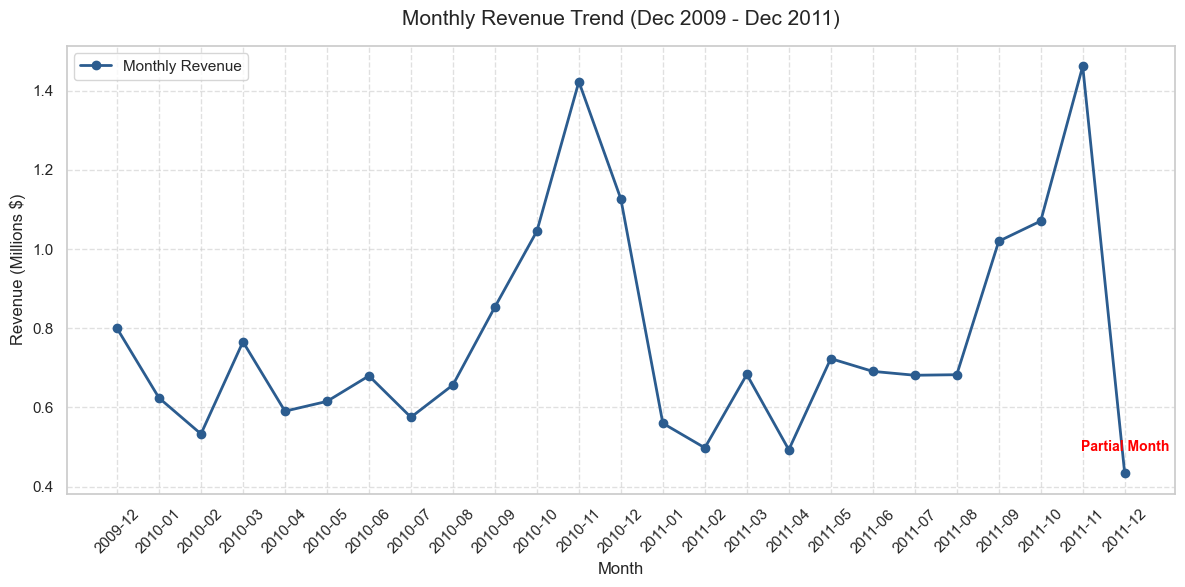

In [7]:
df_temporal = df.copy()
df_temporal['YearMonth'] = df_temporal['InvoiceDate'].dt.to_period('M')

monthly_revenue = df_temporal.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly_revenue['YearMonth_Str'] = monthly_revenue['YearMonth'].astype(str)

plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue['YearMonth_Str'], monthly_revenue['Revenue'] / 1e6, marker='o', color='#2b5c8f', linewidth=2, label='Monthly Revenue')
plt.title('Monthly Revenue Trend (Dec 2009 - Dec 2011)', fontsize=15, pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue (Millions $)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')

# Annotate partial month
plt.text(len(monthly_revenue)-1, monthly_revenue['Revenue'].iloc[-1]/1e6 + 0.05, 'Partial Month', 
         ha='center', va='bottom', color='red', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Correlation Heatmap
We calculate and display a heatmap of the correlation matrix between numerical features.

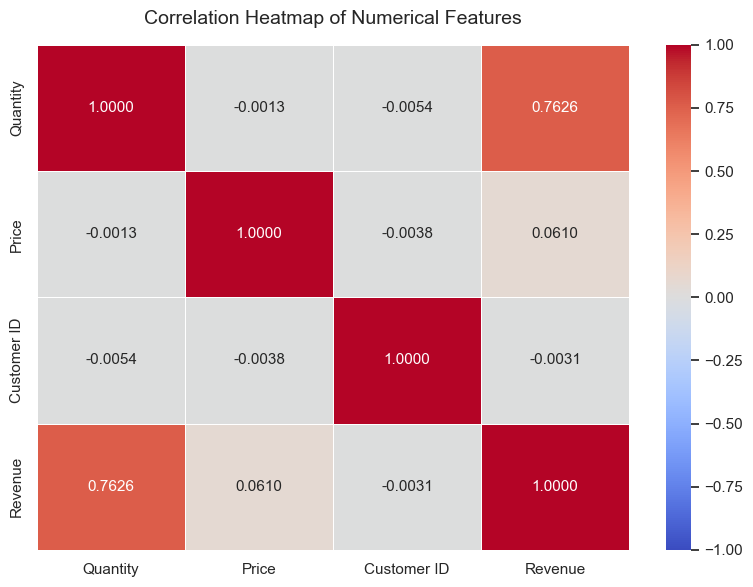

In [8]:
corr_matrix = df[['Quantity', 'Price', 'Customer ID', 'Revenue']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".4f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## 7. Outlier Detection and Visualization
We plot box plots for `Quantity` and `Price` to visualize outliers. We display a full-scale view alongside a zoomed-in view for each feature.

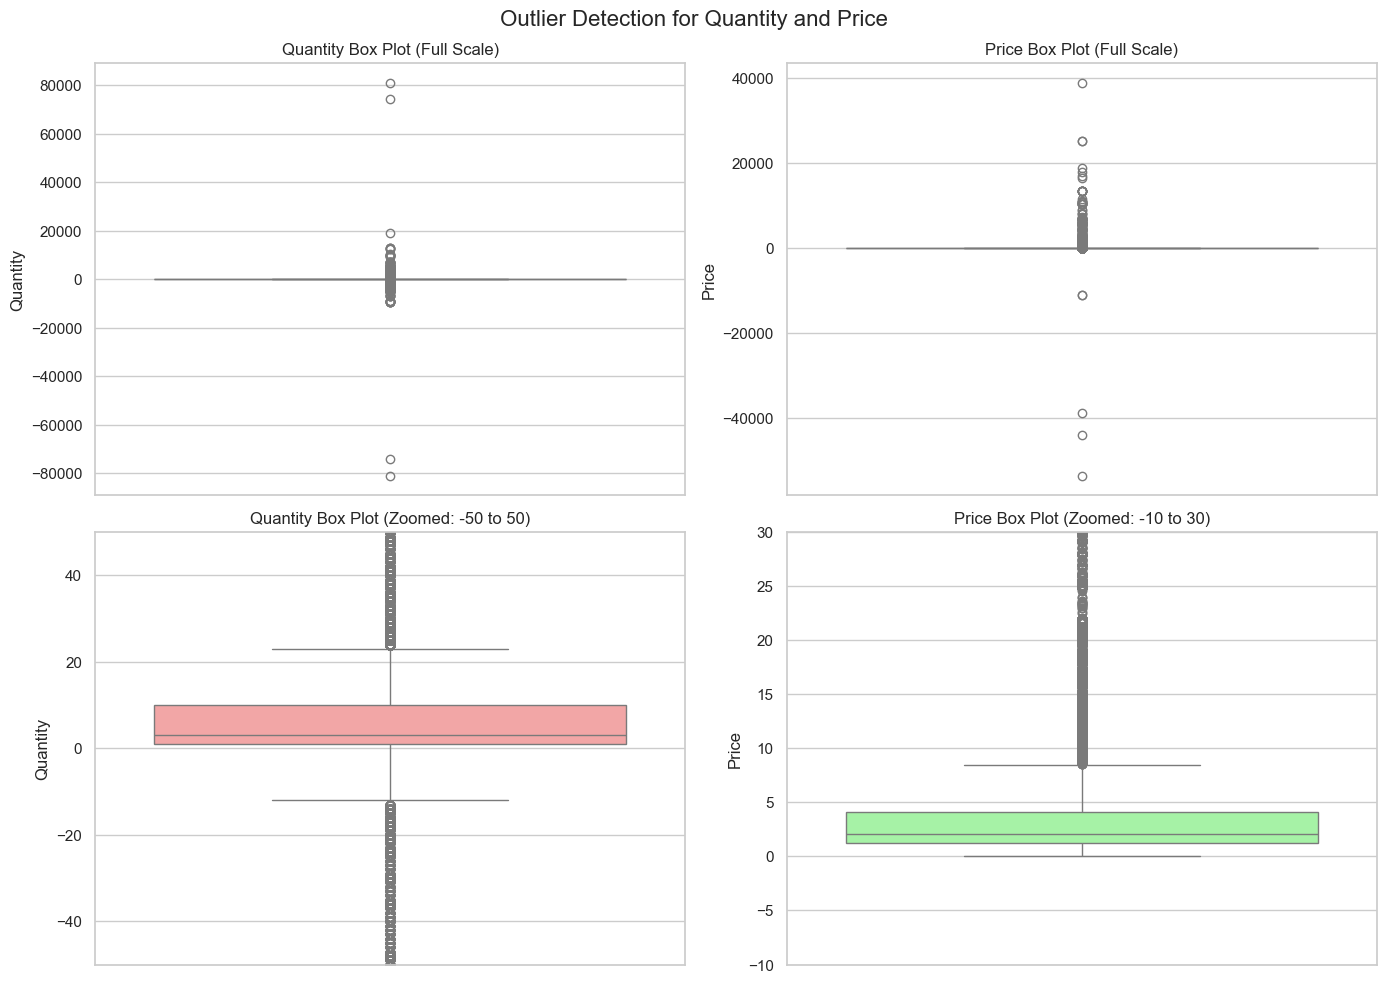

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Quantity Boxplot (Full Scale)
sns.boxplot(y=df['Quantity'], ax=axes[0, 0], color='#ff9999')
axes[0, 0].set_title('Quantity Box Plot (Full Scale)', fontsize=12)
axes[0, 0].set_ylabel('Quantity')

# 2. Price Boxplot (Full Scale)
sns.boxplot(y=df['Price'], ax=axes[0, 1], color='#99ff99')
axes[0, 1].set_title('Price Box Plot (Full Scale)', fontsize=12)
axes[0, 1].set_ylabel('Price')

# 3. Quantity Boxplot (Zoomed Scale)
sns.boxplot(y=df['Quantity'], ax=axes[1, 0], color='#ff9999')
axes[1, 0].set_title('Quantity Box Plot (Zoomed: -50 to 50)', fontsize=12)
axes[1, 0].set_ylabel('Quantity')
axes[1, 0].set_ylim(-50, 50)

# 4. Price Boxplot (Zoomed Scale)
sns.boxplot(y=df['Price'], ax=axes[1, 1], color='#99ff99')
axes[1, 1].set_title('Price Box Plot (Zoomed: -10 to 30)', fontsize=12)
axes[1, 1].set_ylabel('Price')
axes[1, 1].set_ylim(-10, 30)

plt.suptitle('Outlier Detection for Quantity and Price', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

## 8. Business Insights

Based on this exploratory observation, we derive 5 key business insights:

1. **Symmetric Order Cancellations drive Extreme Outliers**:
   Outlier detection shows that the largest transactions are symmetrical cancellations. For example, customer `12346` placed an order of `74,215` units of "MEDIUM CERAMIC TOP STORAGE JAR" on `2011-01-18`, which was cancelled on the same day with a quantity of `-74,215`. Similarly, customer `16446` ordered and cancelled `80,995` units of "PAPER CRAFT , LITTLE BIRDIE" on `2011-12-09`. This highlights that extreme quantity outliers represent administrative errors or bulk-order adjustments rather than actual sales, indicating the need for transaction validation safeguards in order-management systems.

2. **Presence of Large Financial/Non-Product Adjustments**:
   Extreme price outliers are caused by administrative, operational, or shipping fees rather than actual products. Stock codes like `M` (Manual adjustments), `B` (Adjust bad debt), and `AMAZONFEE` have very large values (e.g. bad debt adjustments of over $50,000, and large Amazon fee deductions). These represent operational expenses and ledger adjustments, indicating that standard customer-retail analysis must filter out these entries to avoid skewing average transaction metrics.

3. **High holiday Seasonality**:
   The monthly revenue trend demonstrates clear retail seasonality. Sales peak dramatically in **November 2010 ($1.42M)** and **November 2011 ($1.46M)**, representing the pre-Christmas holiday buying rush. Conversely, January and February show a steep decline, indicating post-holiday lulls. Note that **December 2011** appears lower because the data collection ends on **December 9, 2011**, leaving it as a partial month.

4. **Geographic Concentration Risk (UK Dominance)**:
   Geographic sales analysis shows that the business is overwhelmingly dependent on the **United Kingdom**, which generates **$16.38M in revenue (approx. 92.3% of the total revenue)**. The next highest markets are **EIRE ($615k)** and the **Netherlands ($548k)**. To mitigate the risks of geographic concentration, the company should investigate targeted marketing and distribution partnerships to scale operations across Europe.

5. **Weak Linear Correlation between Features**:
   The correlation matrix reveals that `Quantity` and `Price` have almost zero correlation (`-0.0013`). This indicates that price changes do not exhibit a simple linear relationship with volume at an aggregated level. Additionally, `Revenue` has a very high correlation with `Quantity` (`0.7626`) but much lower with `Price` (`0.0610`), showing that the volume of units sold is the primary driver of top-line revenue growth rather than unit prices.